In [11]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [25]:
# Update this path to match your dataset name in /kaggle/input/
TRAIN_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
TEST_DIR  = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"
OUT_DIR   = "/kaggle/working"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
NUM_CLASSES = 4
EPOCHS_HEAD = 25
EPOCHS_FINE_TUNE = 25

In [13]:
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,  
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, 
    label_mode="categorical",
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, 
    label_mode="categorical",
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE, 
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds_full.class_names
print("Classes:", class_names)

Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [14]:
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15, 
    subset="training", seed=SEED,
    image_size=IMG_SIZE, 
    batch_size=BATCH_SIZE, 
    label_mode="categorical",
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset="validation", 
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical", 
    shuffle=False,
)

class_names = train_ds_full.class_names
print("Classes:", class_names)

Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


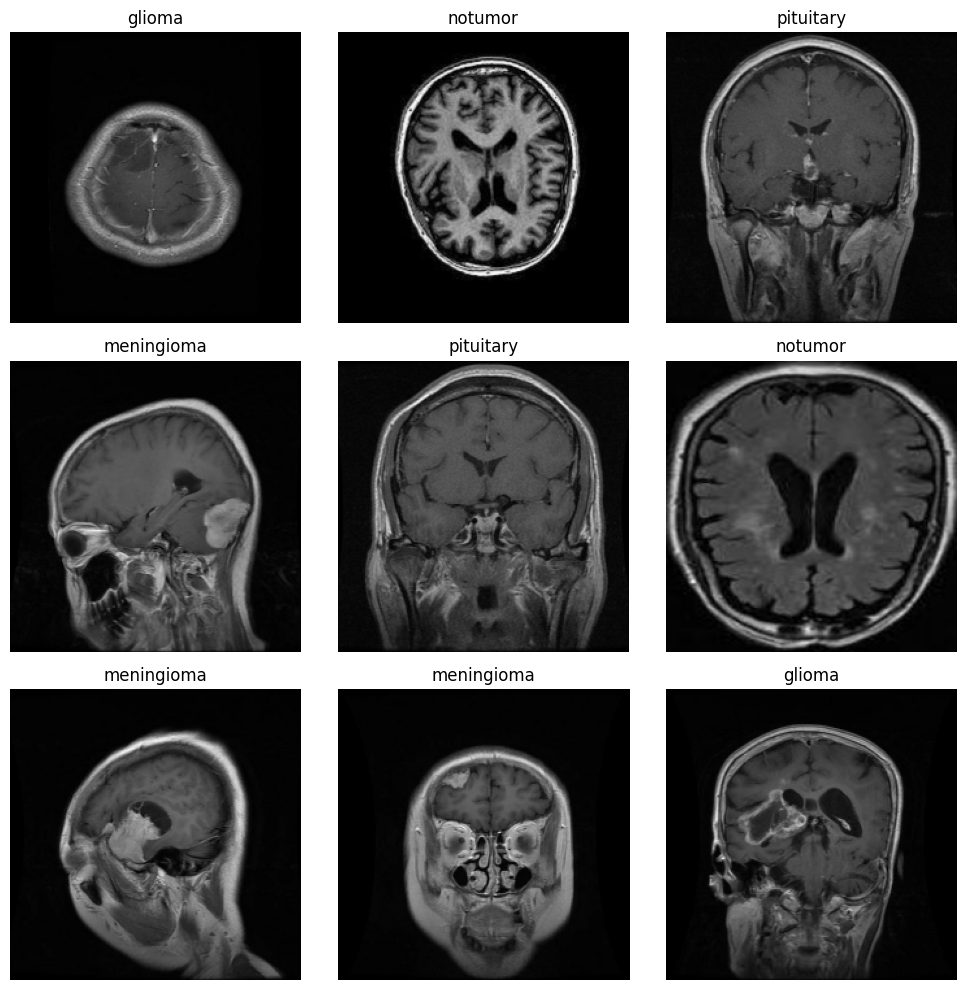

In [15]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds_full.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

def prep(ds, augment=False, shuffle=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                     num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = prep(train_ds_full, augment=True, shuffle=True)
val_ds_p = prep(val_ds)
test_ds_p = prep(test_ds)

In [17]:
base_model = VGG16(include_top=False,
                   weights="imagenet", 
                   input_shape=IMG_SIZE + (3,))
base_model.trainable = False  # freeze for stage 1

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="categorical_crossentropy", 
              metrics=["accuracy"])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ input_layer_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ input_layer_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ input_layer_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      1,028 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", 
                  patience=5,
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss",
                      factor=0.5,
                      patience=3,
                      min_lr=1e-7),
    ModelCheckpoint(f"{OUT_DIR}/best_stage1.keras", monitor="val_accuracy", save_best_only=True),
]

history1 = model.fit(train_ds, validation_data=val_ds_p, epochs=EPOCHS_HEAD, callbacks=callbacks)

Epoch 1/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 38s 212ms/step - accuracy: 0.8721 - loss: 0.3307 - val_accuracy: 0.9167 - val_loss: 0.2372 - learning_rate: 5.0000e-04
Epoch 2/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 37s 221ms/step - accuracy: 0.8725 - loss: 0.3283 - val_accuracy: 0.9119 - val_loss: 0.2485 - learning_rate: 5.0000e-04
Epoch 3/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 207ms/step - accuracy: 0.8821 - loss: 0.3089 - val_accuracy: 0.9119 - val_loss: 0.2361 - learning_rate: 5.0000e-04
Epoch 4/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 37s 220ms/step - accuracy: 0.8731 - loss: 0.3175 - val_accuracy: 0.9179 - val_loss: 0.2184 - learning_rate: 5.0000e-04
Epoch 5/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 211ms/step - accuracy: 0.8815 - loss: 0.3133 - val_accuracy: 0.9167 - val_loss: 0.2152 - learning_rate: 5.0000e-04
Epoch 6/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 36s 218ms/step - accuracy: 0.8826 - loss: 0.3072 - val_accuracy: 0.9238 - val_loss: 0.2371 - learning_rate: 5.0000e-04
Epoch 7/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 36s 21

In [24]:
base_model.trainable = True
for layer in base_model.layers[:-4]:   # unfreeze only last conv block
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="categorical_crossentropy", 
              metrics=["accuracy"])

callbacks_ft = [
    EarlyStopping(monitor="val_loss",
                  patience=6,
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss",
                      factor=0.5, 
                      patience=3,
                      min_lr=1e-8),
    ModelCheckpoint(f"{OUT_DIR}/best_finetuned.keras", monitor="val_accuracy", save_best_only=True),
]

history2 = model.fit(train_ds, validation_data=val_ds_p, epochs=EPOCHS_FINE_TUNE, callbacks=callbacks_ft)

Epoch 1/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 48s 269ms/step - accuracy: 0.8968 - loss: 0.2628 - val_accuracy: 0.9202 - val_loss: 0.1949 - learning_rate: 1.0000e-05
Epoch 2/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 40s 244ms/step - accuracy: 0.9160 - loss: 0.2154 - val_accuracy: 0.9310 - val_loss: 0.1963 - learning_rate: 1.0000e-05
Epoch 3/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 40s 244ms/step - accuracy: 0.9351 - loss: 0.1854 - val_accuracy: 0.9333 - val_loss: 0.1513 - learning_rate: 1.0000e-05
Epoch 4/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 40s 244ms/step - accuracy: 0.9399 - loss: 0.1584 - val_accuracy: 0.9369 - val_loss: 0.1573 - learning_rate: 1.0000e-05
Epoch 5/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 40s 244ms/step - accuracy: 0.9485 - loss: 0.1397 - val_accuracy: 0.9440 - val_loss: 0.1460 - learning_rate: 1.0000e-05
Epoch 6/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 40s 243ms/step - accuracy: 0.9519 - loss: 0.1287 - val_accuracy: 0.9476 - val_loss: 0.1573 - learning_rate: 1.0000e-05
Epoch 7/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 40s 24

In [26]:
test_loss, test_acc = model.evaluate(test_ds_p)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)
y_pred_probs = model.predict(test_ds_p)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.9369 - loss: 0.4276
Test Accuracy: 0.9369 | Test Loss: 0.4276
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step
              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.90      0.95      0.92       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.96      1.00      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



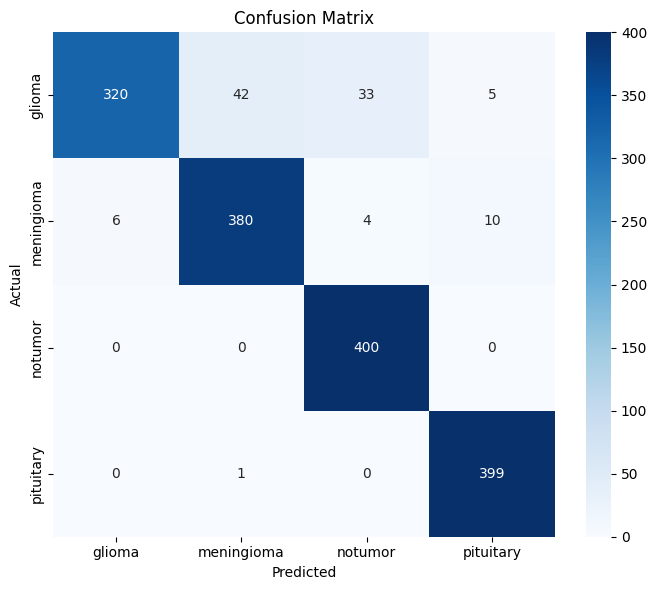

In [27]:
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

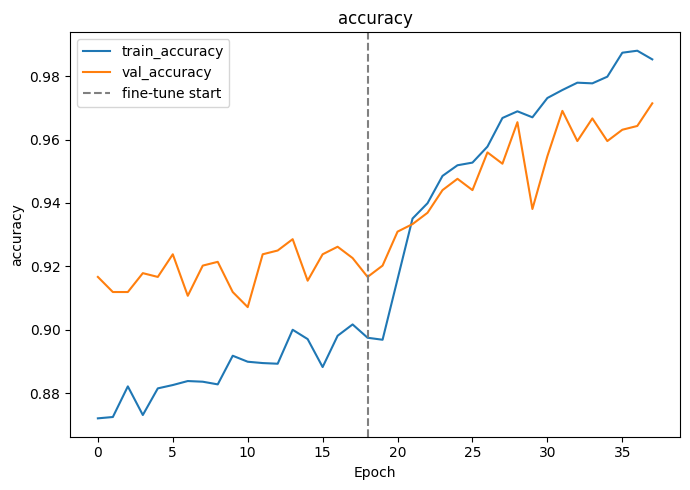

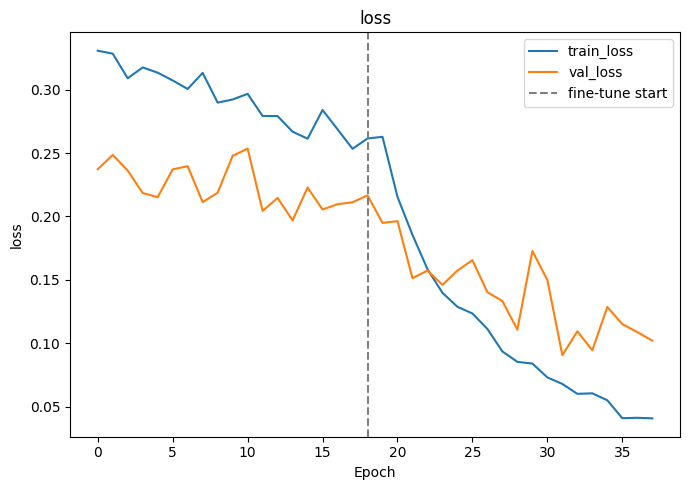

In [28]:
def plot_curve(h1, h2, key, fname):
    vals = h1.history[key] + h2.history[key]
    val_vals = h1.history[f"val_{key}"] + h2.history[f"val_{key}"]
    plt.figure(figsize=(7, 5))
    plt.plot(vals, label=f"train_{key}")
    plt.plot(val_vals, label=f"val_{key}")
    plt.axvline(len(h1.history[key]) - 1, color="gray", linestyle="--", label="fine-tune start")
    plt.xlabel("Epoch"); plt.ylabel(key); plt.legend(); plt.title(key)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}", dpi=150); plt.show()

plot_curve(history1, history2, "accuracy", "accuracy_curve.png")
plot_curve(history1, history2, "loss", "loss_curve.png")

In [30]:
model.save(f"{OUT_DIR}/mri_tumor_vgg16_final.keras")
print("Saved to", f"{OUT_DIR}/mri_tumor_vgg16_final.keras")

Saved to /kaggle/working/mri_tumor_vgg16_final.keras
